## 📖 Introduction

[Consistency Models](https://arxiv.org/abs/2303.01469) are a new family of generative models that achieve high sample quality without adversarial training. They support fast one-step generation by design, while still allowing for few-step sampling to trade compute for sample quality. They also support zero-shot data editing, like image inpainting, colorization, and super-resolution, without requiring explicit training on these tasks.


### Key Idea

_Learn a model that maps any arbitrary point in the latent space to the initial data point, i.e: if points lie on the same probability flow trajectory they are mapped to the same initial data point._

### Contributions

- Single step sampling
- Zero-shot data editing: inpainting, outpainting e.t.c

### Definition

Given a diffusion trajectory $x_{\sigma \in \left[\sigma_{min}, \sigma_{max}\right]}$, we define a consistency function $f : \left(x_{\sigma}, \sigma\right) \rightarrow x_{\sigma_{min}}$.

We can then train a consistency model $f_{\theta}\left(., . \right)$ to approximate the consistency function. A property of the consistency function is that $f : \left(x_{\sigma_{min}}, \sigma_{min} \right) \rightarrow x_{\sigma_{min}}$. To achieve this we parameterize the consistency model using skip connections as in [[2]](#2)

$$
f_{\theta}\left(x_{\sigma}, \sigma \right) = c_{skip}\left(\sigma \right)x_{\sigma} + c_{out}\left(\sigma \right)F_{\theta}\left(x_{\sigma}, \sigma \right)
$$

where $c_{skip}\left(\sigma_{min} \right) = 1$ and $c_{out}\left(\sigma_{min} \right) = 0$ and $F_{\theta}\left(.,.\right)$ is the neural network.

### Algorithms

#### Training

To train the model we follow the following algorithm:

```python
for current_training_step in range(total_training_steps):
    data = data_distribution()

  num_timesteps = timestep_schedule(current_training_step, total_training_steps, initial_timesteps, final_timesteps)
  sigmas = karras_schedule(num_timesteps, sigma_min, sigma_max)
  timesteps = uniform_distribution(batch_size, start=0, end=num_timesteps-1)
  noise = standard_gaussian_noise()

  current_sigmas = sigmas[timesteps]
  next_sigmas = sigmas[timesteps + 1]

  current_noisy_data = data + current_sigmas * noise
  next_noisy_data = data + next_sigmas * noise

  student_model_prediction = (skip_scaling(next_sigmas, sigma_data, sigma_min) * next_noisy_data
                            + output_scaling(next_sigmas, sigma_data, sigma_min) * student_model(next_noisy_data, next_sigmas))

  with no_grad():
      teacher_model_prediction = (skip_scaling(current_sigmas, sigma_data, sigma_min) * current_noisy_data
                                + output_scaling(current_sigmas, sigma_data, sigma_min) * teacher_model(current_noisy_data, next_sigmas))

  loss = distance_metric(student_model_prediction, teacher_model_prediction)

  loss.backward()

  with no_grad():
    current_ema_decay_rate = ema_decay_schedule(current_training_step, initial_ema_decay_rate, initial_timesteps)
    teacher_model_params = current_ema_decay_rate * teacher_model_params + (1 - current_ema_decay_rate) * student_model_params

```

#### Sampling

Starting from an initial random noise $\hat{x}_{\sigma_{max}} \sim \mathcal{N}(0, \sigma_{max}^2I)$, the consistency model can be used to sample a point in a single step: $\hat{x}_{\sigma_{min}} = f_{\theta}(x_{\sigma_{max}}, \sigma_{max})$. For iterative refinement, the following algorithm can be used:

```python
# Generate an initial sample from the initial random noise
sample = (skip_scaling(sigma_max, sigma_data, sigma_min) * x_sigma_max
                + output_scaling(sigma_max, sigma_data, sigma_min) * model(x_sigma_max, sigma_max))
sample = clamp?(sample)

for sigma in sigmas:
    noise = standard_gaussian_noise()
    noisy_sample = sample + square_root(square(sigma) - square(sigma_min)) * noise
    sample = (skip_scaling(sigma, sigma_data, sigma_min) * noisy_sample
                + output_scaling(sigma, sigma_data, sigma_min) * model(noisy_sample, sigma))
    sample = clamp?(sample)
```

where `consistency_model` $= f_{\theta}\left(.,.\right)$,
`clamp?` is a function that optionally clips values to a given range.

### References

<a id="1">[1]</a> Song, Y., Dhariwal, P., Chen, M., &amp; Sutskever, I. (2023, May 31). Consistency models. arXiv.org. https://arxiv.org/abs/2303.01469

<a id="2">[2]</a> Karras, T., Aittala, M., Aila, T., &amp; Laine, S. (2022, October 11). Elucidating the design space of diffusion-based Generative Models. arXiv.org. https://arxiv.org/abs/2206.00364

# Consistency Models Training Example

[![arXiv](https://img.shields.io/badge/arXiv-2301.01469-<COLOR>.svg)](https://arxiv.org/abs/2303.01469) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kinyugo/consistency_models/blob/main/notebooks/consistency_models_training_example.ipynb) [![GitHub Repo stars](https://img.shields.io/github/stars/Kinyugo/consistency_models?style=social) ](https://github.com/Kinyugo/consistency_models)

## 🛠️ Setup


### GPU Check

In [4]:
!nvidia-smi

Tue Mar 17 10:21:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   25C    P8             24W /  300W |       1MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Packages Installation

> **NOTE:** Restart the runtime if using colab after installing the packages.

In [5]:
#%pip install -q lightning gdown torchmetrics einops torchinfo lpips --no-cache --upgrade
#%pip install -q -e git+https://github.com/Kinyugo/consistency_models.git#egg=consistency_models

In [6]:
%env CUDA_VISIBLE_DEVICES=2

env: CUDA_VISIBLE_DEVICES=2


### Imports

In [7]:
import json
import os
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningDataModule, LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchinfo import summary
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

import sys
sys.path.append("../..")

from consistency_models.consistency_models_obs_cond_few_steps_time_embedding import (
    ConsistencySamplingAndEditingFewSteps_TimeEmbedding,
    ConsistencyTrainingFewSteps_TimeEmbedding,
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_

## 🧠  Implementation

#### DataModule

Norm stats (0.3047108663749711, 0.3879814586804132)
torch.Size([1, 15, 128, 128])


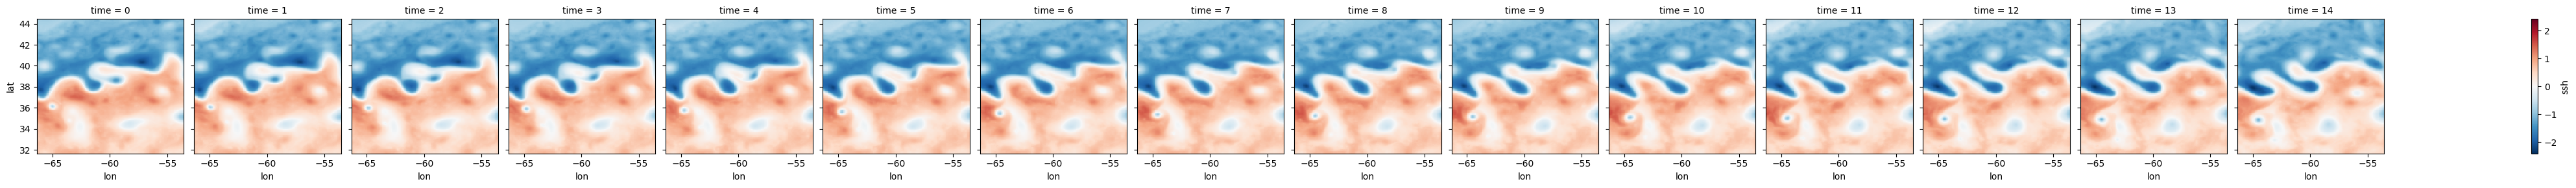

In [8]:
import sys
import pyinterp
import pyinterp.fill
import pyinterp.backends.xarray
sys.path.append('../../..')
from src.data_notebook import *

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
import torch
import itertools

lon_min = -66.3 
lon_max = -53.5
lat_min = 31.7
lat_max = 44.5

datadir="/dmidata/users/maxb/NATL_dataset"

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

def remove_nan(da):
    da["lon"] = da.lon.assign_attrs(units="degrees_east")
    da["lat"] = da.lat.assign_attrs(units="degrees_north")

    da.transpose("lon", "lat", "time")[:, :] = pyinterp.fill.gauss_seidel(
        pyinterp.backends.xarray.Grid3D(da)
    )[1]
    return da

def load_altimetry_data(path, obs_from_tgt=False):
    ds =  (
        xr.open_dataset(path)
        # .assign(ssh=lambda ds: ds.ssh.coarsen(lon=2, lat=2).mean().interp(lat=ds.lat, lon=ds.lon))
        .load()
        .assign(
            input=lambda ds: ds.nadir_obs,
            tgt=lambda ds: remove_nan(ds.ssh),
        )    
    )

    if obs_from_tgt:
        ds = ds.assign(input=ds.tgt.where(np.isfinite(ds.input), np.nan))
    
    return (
        ds[[*TrainingItem._fields]]
        .transpose("time", "lat", "lon")
        .to_array()
    )

datamodule = BaseDataModule(input_da=load_altimetry_data(datadir+"/natl_gf_w_5nadirs_swot.nc"),
                            domains={'train': {'time': slice('2013-02-24', '2013-09-30',)},
                                     'val': {'time': slice('2012-12-15', '2013-02-24',)},
                                     'test': {'time': slice('2012-10-01', '2012-12-20',)}},
                            xrds_kw={'patch_dims': {'time': 15, 'lat': 128, 'lon': 128},
                                     'strides': {'time': 1, 'lat': 128, 'lon': 128},
                                     'domain_limits':  dict(lon=slice(lon_min, lon_max,),
                                                            lat=slice(lat_min, lat_max,))},
                            dl_kw={'batch_size': 1, 'num_workers': 1},
                            grad=False,
                            #aug_kw={'aug_factor': 1, 'aug_only': True},
                            resize_factor=2)
datamodule.setup()


# datamodule.train_ds[0].input has shape (15, 240, 240)
xr.Dataset(data_vars={'ssh':(('time','lat','lon'),datamodule.train_ds[0].tgt)},
           coords={'time':np.arange(15),
                   'lon':np.arange(lon_min, lon_max, 0.1),
                   'lat':np.arange(lat_min, lat_max, 0.1)}).ssh.plot(col='time',col_wrap=15)

data_loader = datamodule.train_dataloader()
k=10
my_sample = next(itertools.islice(data_loader, k, None))
print(my_sample[0].shape)

### Modules

In [9]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        n_heads: int = 8,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()

        self.dropout = dropout

        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)

        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])

        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        time_level_channels: int,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()

        self.input_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)

        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        time_level_channels: int,
        n_heads: int = 8,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()

        self.unet_block = UNetBlock(
            in_channels, out_channels, time_level_channels, dropout
        )
        self.self_attention = SelfAttention(
            out_channels, out_channels, n_heads, dropout
        )

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()

        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()

        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeLevelEmbedding(nn.Module):
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()

        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)

        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)

        return self.projection(h)

### UNet

Our UNet is inspired by Stable Diffusion and Imagen. It's not the same UNet as the paper.

In [10]:
@dataclass
class UNetConfig:
    channels: int = 15
    time_level_channels: int = 256
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (128, 128)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (256, 512)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)

class UNet(nn.Module):
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()

        self.config = config

        self.input_projection = nn.Conv2d(
            config.channels*3,
            config.top_blocks_channels[0],
            kernel_size=3,
            padding="same",
        )
        self.time_level_embedding = TimeLevelEmbedding(
            config.time_level_channels, config.time_level_scale
        )
        self.top_encoder_blocks = self._make_encoder_blocks(
            self.config.top_blocks_channels + self.config.mid_blocks_channels[:1],
            self.config.top_blocks_n_blocks_per_resolution,
            self.config.top_blocks_has_resampling,
            self.config.top_blocks_dropout,
            self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            self.config.mid_blocks_channels + self.config.mid_blocks_channels[-1:],
            self.config.mid_blocks_n_blocks_per_resolution,
            self.config.mid_blocks_has_resampling,
            self.config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            self.config.mid_blocks_channels + self.config.mid_blocks_channels[-1:],
            self.config.mid_blocks_n_blocks_per_resolution,
            self.config.mid_blocks_has_resampling,
            self.config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            self.config.top_blocks_channels + self.config.mid_blocks_channels[:1],
            self.config.top_blocks_n_blocks_per_resolution,
            self.config.top_blocks_has_resampling,
            self.config.top_blocks_dropout,
            self._make_top_block,
        )
        self.output_projection = nn.Conv2d(
            config.top_blocks_channels[0],
            config.channels,
            kernel_size=3,
            padding="same",
        )

    def forward(self, x: torch.Tensor, y: torch.Tensor, time: torch.Tensor, time_prime: torch.Tensor) -> torch.Tensor:
        
        mask_obs = ~torch.isnan(y)
        y = torch.nan_to_num(y)  
        h = self.input_projection(torch.cat((x, y, mask_obs), 1))

        emb1 = self.time_level_embedding(time)
        emb2 = self.time_level_embedding(time_prime)
        time_level = torch.cat([emb1, emb2], dim=1)
    
        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        return self.output_projection(h)

    def _make_encoder_blocks(
        self,
        channels: Tuple[int, ...],
        n_blocks_per_resolution: Tuple[int, ...],
        has_resampling: Tuple[bool, ...],
        dropout: Tuple[float, ...],
        block_fn: Callable[[], nn.Module],
    ) -> nn.ModuleList:
        blocks = nn.ModuleList()

        channel_pairs = list(zip(channels[:-1], channels[1:]))
        for idx, (in_channels, out_channels) in enumerate(channel_pairs):
            for _ in range(n_blocks_per_resolution[idx]):
                blocks.append(block_fn(in_channels, out_channels, dropout[idx]))
                in_channels = out_channels

            if has_resampling[idx]:
                blocks.append(Downsample(out_channels))

        return blocks

    def _make_decoder_blocks(
        self,
        channels: Tuple[int, ...],
        n_blocks_per_resolution: Tuple[int, ...],
        has_resampling: Tuple[bool, ...],
        dropout: Tuple[float, ...],
        block_fn: Callable[[], nn.Module],
    ) -> nn.ModuleList:
        blocks = nn.ModuleList()

        channel_pairs = list(zip(channels[:-1], channels[1:]))[::-1]
        for idx, (out_channels, in_channels) in enumerate(channel_pairs):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(in_channels))

            inner_blocks = []
            for _ in range(n_blocks_per_resolution[::-1][idx]):
                inner_blocks.append(
                    block_fn(in_channels * 2, out_channels, dropout[::-1][idx])
                )
                out_channels = in_channels
            blocks.extend(inner_blocks[::-1])

        return blocks

    def _make_top_block(
        self, in_channels: int, out_channels: int, dropout: float
    ) -> UNetBlock:
        return UNetBlock(
            in_channels,
            out_channels,
            2*self.config.time_level_channels,
            dropout,
        )

    def _make_mid_block(
        self,
        in_channels: int,
        out_channels: int,
        dropout: float,
    ) -> UNetBlockWithSelfAttention:
        return UNetBlockWithSelfAttention(
            in_channels,
            out_channels,
            2*self.config.time_level_channels,
            self.config.n_heads,
            dropout,
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)

        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)

        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        config = UNetConfig(**config_dict)

        model = cls(config)

        state_dict = torch.load(
            os.path.join(pretrained_path, "model.pt"), map_location=torch.device("cpu")
        )
        model.load_state_dict(state_dict)

        return model


summary(UNet(UNetConfig()), 
        input_size=((1, 15, 128, 128), 
                    (1, 15, 128, 128), 
                    (1,), (1,)
                   )
       )

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 15, 128, 128]         --
├─Conv2d: 1-1                                 [1, 128, 128, 128]        51,968
├─TimeLevelEmbedding: 1-2                     [1, 256, 1, 1]            128
│    └─Sequential: 2-1                        [1, 256, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 1024]                 263,168
│    │    └─SiLU: 3-2                         [1, 1024]                 --
│    │    └─Linear: 3-3                       [1, 256]                  262,400
│    │    └─Rearrange: 3-4                    [1, 256, 1, 1]            --
├─TimeLevelEmbedding: 1-3                     [1, 256, 1, 1]            (recursive)
│    └─Sequential: 2-2                        [1, 256, 1, 1]            (recursive)
│    │    └─Linear: 3-5                       [1, 1024]                 (recursive)
│    │    └─SiLU: 3-6                         [1, 102

### LitUNet

In [11]:
@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000


class LitConsistencyModel(LightningModule):
    def __init__(
        self,
        consistency_training,   # ConsistencyTrainingFewSteps_TimeEmbedding or _LearnedSDE
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()

        self.consistency_training = consistency_training
        self.student_model = student_model
        self.teacher_model = teacher_model
        self.ema_student_model = ema_student_model
        self.config = config
        self.num_timesteps = self.consistency_training.initial_timesteps

        # Freeze teacher and EMA student models
        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def on_train_epoch_start(self) -> None:
        print(f"[Epoch {self.current_epoch}] num_timesteps={self.num_timesteps}")

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            batch.tgt,
            batch.input,
            self.global_step,
            10000,
        )
        self.num_timesteps = output.num_timesteps

        if batch_idx == 0:
            print(f"[Epoch {self.current_epoch}] sigmas={output.sigmas}")

        loss = F.mse_loss(
            output.predicted_next_from_intermediate,
            output.target_next_from_current,
        )
        self.log_dict({
            "train_loss":    loss,
            "num_timesteps": float(output.num_timesteps),
        })

        return loss

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        ema_decay_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model, self.student_model, ema_decay_rate)
        self.log_dict({"ema_decay_rate": ema_decay_rate})
        update_ema_model_(
            self.ema_student_model,
            self.student_model,
            self.config.student_model_ema_decay_rate,
        )

    def configure_optimizers(self):
        params = list(self.student_model.parameters())
        opt = torch.optim.Adam(params, lr=self.config.lr, betas=self.config.betas)
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]

## 🚀 Training

### Training Loop

In [15]:
import os
import zipfile
import glob

def is_valid_checkpoint(path: str) -> bool:
    """Vérifie qu'un checkpoint Lightning est un zip valide (non corrompu)."""
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    """
    Cherche le meilleur checkpoint valide dans ckpt_dir.
    Priorité : last.ckpt d'abord, puis les checkpoints nommés par métrique
    (triés par train_loss croissante, i.e. meilleur en premier).
    Retourne None si aucun checkpoint valide n'est trouvé.
    """
    if not os.path.isdir(ckpt_dir):
        return None

    # 1. Essayer last.ckpt en priorité
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt):
        if is_valid_checkpoint(last_ckpt):
            print(f"✅ Checkpoint valide trouvé : {last_ckpt}")
            return last_ckpt
        else:
            print(f"⚠️  last.ckpt corrompu, recherche d'un meilleur checkpoint...")

    # 2. Chercher les autres checkpoints et les trier par loss (croissant)
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt")) if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf")
    )

    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"✅ Checkpoint valide trouvé : {ckpt_path}")
            return ckpt_path
        else:
            print(f"⚠️  Corrompu, ignoré : {ckpt_path}")

    print("❌ Aucun checkpoint valide trouvé. Démarrage depuis zéro.")
    return None


@dataclass
class TrainingConfig:
    unet_config: UNetConfig
    consistency_training: ConsistencyTrainingFewSteps_TimeEmbedding
    lit_cm_config: LitConsistencyModelConfig
    trainer: Trainer
    seed: int = 42
    log_dir: str = "logs_CT_few_steps_time_embedding"  # répertoire racine unique
    log_version: str = "cm"
    resume_ckpt_path: Optional[str] = None
    reload: bool = False

    @property
    def run_dir(self) -> str:
        return os.path.join(self.log_dir, self.log_version)

    @property
    def model_ckpt_path(self) -> str:
        """Modèle EMA sauvegardé après training."""
        return os.path.join(self.run_dir, "best_model")

    @property
    def lightning_ckpt_dir(self) -> str:
        """Checkpoints Lightning pour reprise de training."""
        return os.path.join(self.run_dir, "checkpoints")


def run_training(config: TrainingConfig) -> None:
    seed_everything(config.seed)
    dm = datamodule

    if not config.reload:
        student_model = UNet(config.unet_config)
    else:
        student_model = UNet.from_pretrained(config.model_ckpt_path)
    teacher_model = UNet(config.unet_config)
    teacher_model.load_state_dict(student_model.state_dict())
    ema_student_model = UNet(config.unet_config)
    ema_student_model.load_state_dict(student_model.state_dict())

    lit_cm = LitConsistencyModel(
        config.consistency_training,
        student_model,
        teacher_model,
        ema_student_model,
        config.lit_cm_config,
    )

    config.trainer.fit(lit_cm, dm, ckpt_path=config.resume_ckpt_path)

    # Sauvegarde du modèle EMA dans le répertoire de logs unifié
    lit_cm.ema_student_model.save_pretrained(config.model_ckpt_path)
    print(f"✅ EMA model saved to: {config.model_ckpt_path}")


### Run Training

In [13]:
%tensorboard --logdir=logs_CT_few_steps_time_embedding --port 6006

UsageError: Line magic function `%tensorboard` not found.


> **NOTE:** While the paper suggests a final_timesteps value of `150`, it's important to note that during my experimentation on a smaller dataset with approximately 10,000 training steps, I discovered that setting final_timesteps to `17` yielded superior results. This value corresponds to the number of timesteps that would be obtained if we were to train for the same number of steps as mentioned in the paper (600,000 to 1,000,000). However, it's crucial to emphasize that this particular setting has not been extensively explored or experimented with, so it may require further fine-tuning and adjustment to suit your specific needs.

In [16]:
from pytorch_lightning.accelerators import find_usable_cuda_devices
from pytorch_lightning.callbacks import ModelCheckpoint

LOG_DIR     = "logs_CT_few_steps_time_embedding"
LOG_VERSION = "cm"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")

resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

ct = ConsistencyTrainingFewSteps_TimeEmbedding(final_timesteps=17)

training_config = TrainingConfig(
    unet_config=UNetConfig(),
    consistency_training=ct,
    lit_cm_config=LitConsistencyModelConfig(
        lr_scheduler_iters=1000,
    ),
    log_dir=LOG_DIR,
    log_version=LOG_VERSION,
    trainer=Trainer(
        accelerator="gpu",
        max_epochs=2500,
        accumulate_grad_batches=4,
        precision="16-mixed",
        log_every_n_steps=1,
        logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
        callbacks=[
            LearningRateMonitor(logging_interval="step"),
            ModelCheckpoint(
                dirpath=CKPT_DIR,
                monitor="train_loss",
                save_top_k=3,
                save_last=True,
                filename="{epoch:03d}-{step}-{train_loss:.4f}",
            ),
        ],
    ),
    resume_ckpt_path=resume_ckpt,
)
run_training(training_config)


⚠️  last.ckpt corrompu, recherche d'un meilleur checkpoint...


Using 16bit Automatic Mixed Precision (AMP)
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42


✅ Checkpoint valide trouvé : logs_CT_few_steps_time_embedding/cm/checkpoints/epoch=948-step=49348-train_loss=0.0000.ckpt


/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory logs_CT_few_steps_time_embedding/cm/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
Restoring states from the checkpoint path at logs_CT_few_steps_time_embedding/cm/checkpoints/epoch=948-step=49348-train_loss=0.0000.ckpt
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory logs_CT_few_steps_time_embedding/cm/checkpoints exis

Training: 0it [00:00, ?it/s]

[Epoch 949] num_timesteps=2
[Epoch 949] sigmas=tensor([0.0000, 0.0256, 0.0513, 0.0769, 0.1026, 0.1282, 0.1538, 0.1795, 0.2051,
        0.2308, 0.2564, 0.2821, 0.3077, 0.3333, 0.3590, 0.3846, 0.4103, 0.4359,
        0.4615, 0.4872, 0.5128, 0.5385, 0.5641, 0.5897, 0.6154, 0.6410, 0.6667,
        0.6923, 0.7179, 0.7436, 0.7692, 0.7949, 0.8205, 0.8462, 0.8718, 0.8974,
        0.9231, 0.9487, 0.9744, 1.0000], device='cuda:0')
[Epoch 949] sigmas=tensor([0.0000, 0.0256, 0.0513, 0.0769, 0.1026, 0.1282, 0.1538, 0.1795, 0.2051,
        0.2308, 0.2564, 0.2821, 0.3077, 0.3333, 0.3590, 0.3846, 0.4103, 0.4359,
        0.4615, 0.4872, 0.5128, 0.5385, 0.5641, 0.5897, 0.6154, 0.6410, 0.6667,
        0.6923, 0.7179, 0.7436, 0.7692, 0.7949, 0.8205, 0.8462, 0.8718, 0.8974,
        0.9231, 0.9487, 0.9744, 1.0000], device='cuda:0')


OSError: [Errno 127] Key has expired

## 🎲 Sampling & Zero-shot Editing

In [ ]:
seed_everything(42)

Global seed set to 42


42

### Utils

In [ ]:
def plot_images(images: Tensor, vmin: float=-2., vmax: float=2., cols: int = 15) -> None:
    xr.Dataset(data_vars={'ssh':(('time','lat','lon'),images.float().cpu())},
           coords={'time':np.arange(images.shape[0]),
                   'lon':np.arange(images.shape[2]),
                   'lat':np.arange(images.shape[1])}).ssh.plot(col='time',col_wrap=cols, 
                                                                  vmin=vmin, vmax=vmax)

### Checkpoint Loading

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

# Modèle EMA chargé depuis le répertoire de logs unifié
MODEL_PATH = os.path.join(LOG_DIR, LOG_VERSION, "best_model")
unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)

### Load Sample Batch

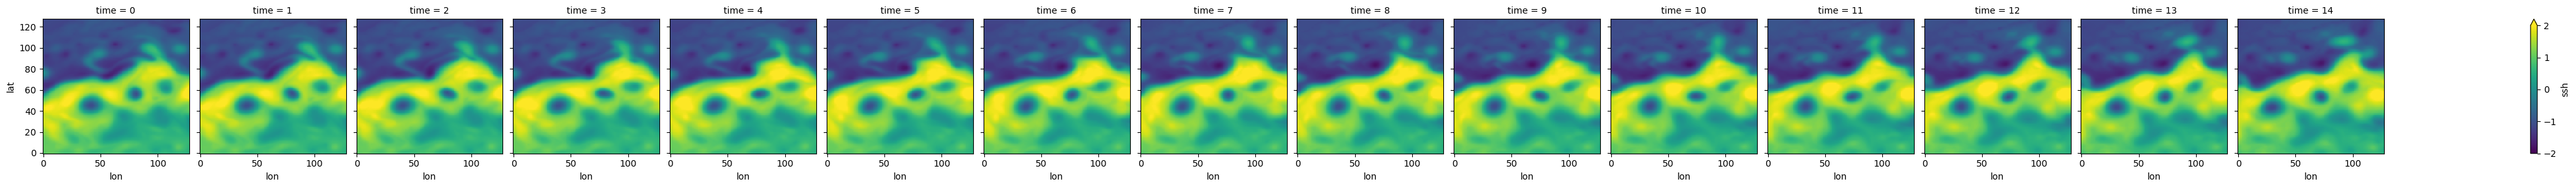

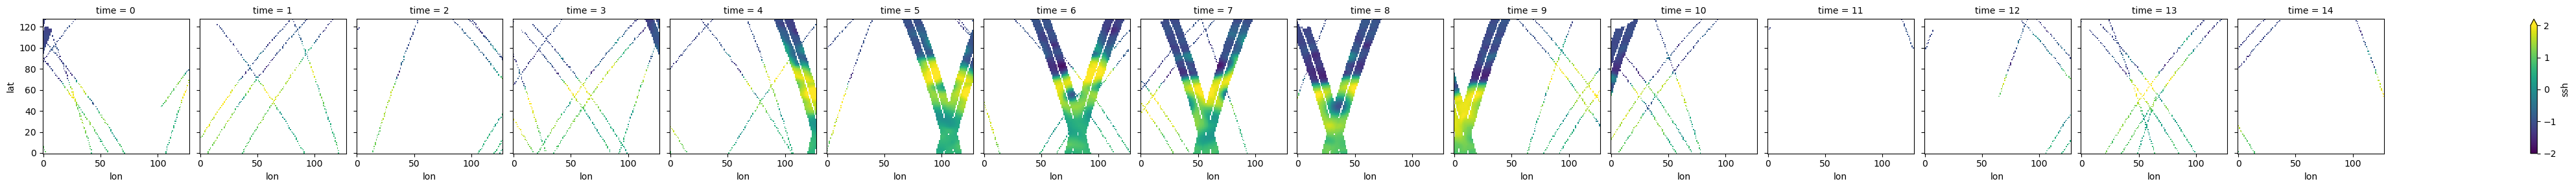

In [ ]:
batch = next(iter(datamodule.train_dataloader()))
plot_images(batch.tgt[0])
plot_images(batch.input[0])

### Experiments

#### Sampling

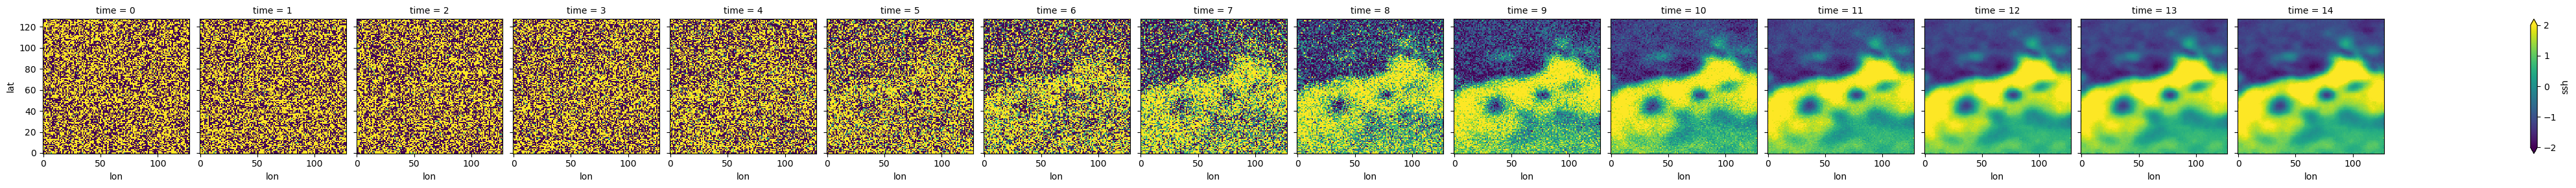

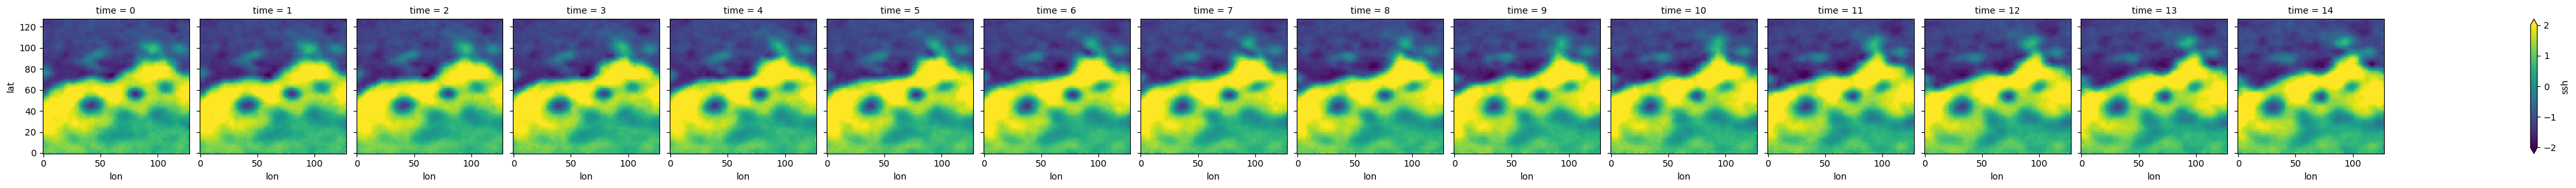

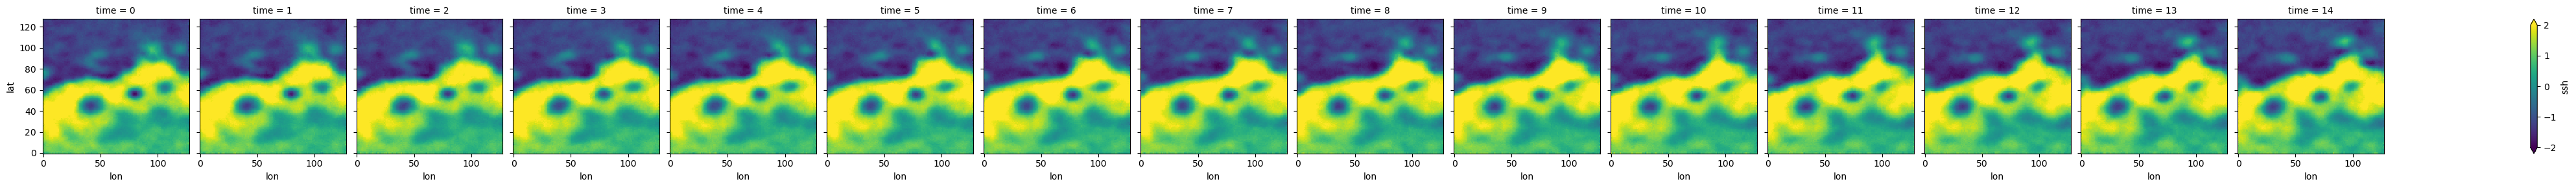

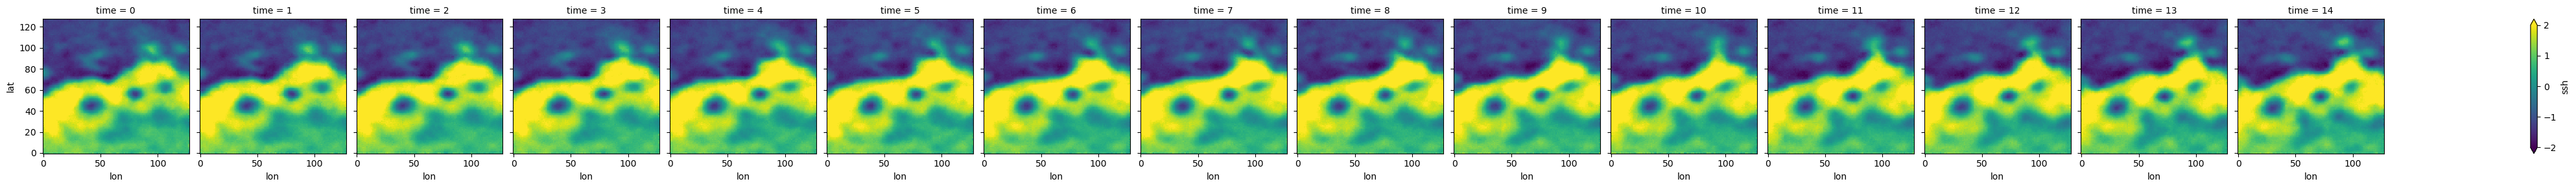

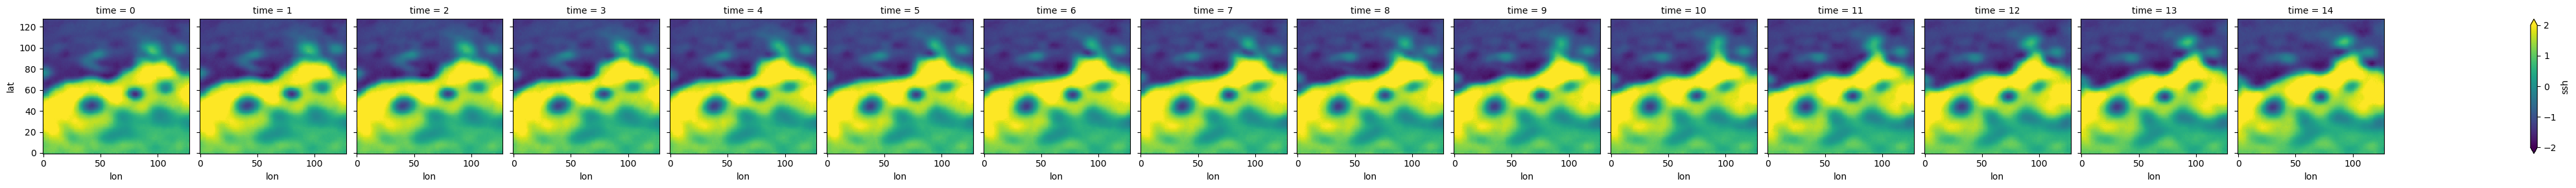

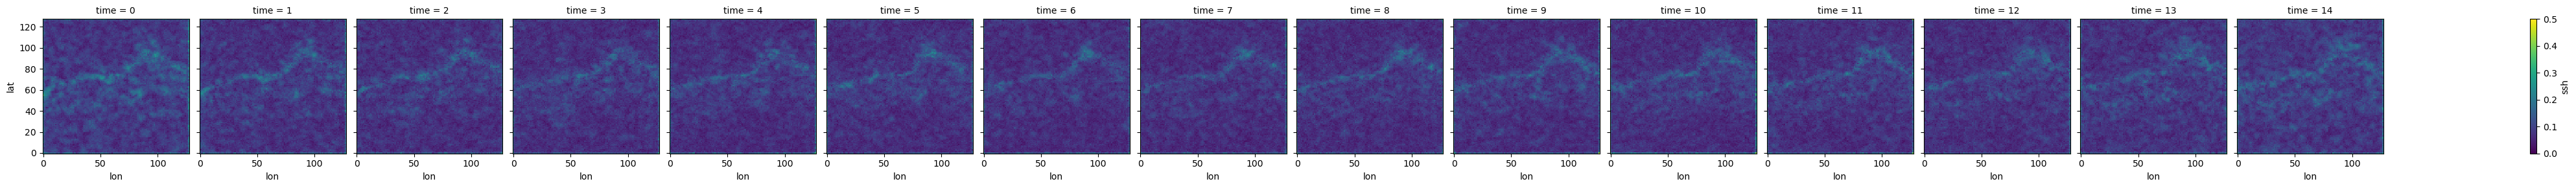

In [ ]:
consistency_sampling_and_editing = ConsistencySamplingAndEditingFewSteps_TimeEmbedding()

with torch.no_grad():
    samples = []
    samples_process = []
    for i in range(10):
        sample, sample_process = consistency_sampling_and_editing(
            unet,
            torch.randn((1, 15, 128, 128), device=device, dtype=dtype),
            batch.input.to(device).to(dtype),
            nsteps=15,
            clip_denoised=False,
            verbose=True,
            stochastic=True,
        )
        samples.append(sample)
        samples_process.append(sample_process)

plot_images(samples_process[1][:,0,7,:,:],cols=15)

plot_images(samples[1][0])
plot_images(samples[2][0])
plot_images(samples[3][0])
plot_images(torch.mean(torch.stack(samples,dim=0),dim=0)[0])
plot_images(torch.std(torch.stack(samples,dim=0),dim=0)[0],vmin=0,vmax=0.5)

In [ ]:
"""
Code pour l'évaluation des métriques de l'ensemble
À copier-coller dans une cellule du notebook après la cellule de sampling
"""

import numpy as np
from scipy import signal
import pandas as pd
from properscoring import crps_ensemble

# Stack samples into ensemble (10 samples, 1 batch, 15 time, 128 lat, 128 lon)
ensemble = torch.stack(samples, dim=0).squeeze(1)  # Shape: (10, 15, 128, 128)
ensemble_mean = ensemble.mean(dim=0)  # Shape: (15, 128, 128)

# Ground truth
gt = batch.tgt[0].cpu().numpy()  # Shape: (15, 128, 128)
ensemble_mean_np = ensemble_mean.float().cpu().numpy()
ensemble_np = ensemble.float().cpu().numpy()

# Mask for valid data (non-NaN in ground truth)
valid_mask = ~np.isnan(gt)

# 1. mu score = 1 - RMSE/std(GT)
gt_std = np.nanstd(gt)
rmse = np.sqrt(np.nanmean((ensemble_mean_np - gt)**2))
mu_score = 1 - (rmse / gt_std)

# 2. RMSE (already calculated above)
rmse_value = rmse

# 3. CRPS (Continuous Ranked Probability Score)
# CRPS needs to be computed per point, then averaged
crps_values = []
for t in range(gt.shape[0]):
    for i in range(gt.shape[1]):
        for j in range(gt.shape[2]):
            if valid_mask[t, i, j]:
                # Get ensemble members for this point
                ens_point = ensemble_np[:, t, i, j]
                gt_point = gt[t, i, j]
                crps_values.append(crps_ensemble(gt_point, ens_point))

crps_mean = np.mean(crps_values)

# 4. Spectral metrics (lambda_x) - minimal resolution reconstructed
# Compute 2D power spectral density and find where it drops to 50% of peak
def compute_psd_and_lambda_x(field, dx=1.0):
    """
    Compute PSD and find the wavelength at which PSD drops to 50% of peak
    dx: grid spacing in km (assuming uniform grid)
    """
    # Remove NaNs for spectral analysis
    field_valid = field.copy()
    field_valid[np.isnan(field_valid)] = 0
    
    # Compute 2D FFT for each time step and average
    psd_sum = 0
    for t in range(field_valid.shape[0]):
        fft2d = np.fft.fft2(field_valid[t])
        psd2d = np.abs(fft2d)**2
        psd_sum += psd2d
    
    psd_avg = psd_sum / field_valid.shape[0]
    
    # Compute radial average of PSD
    ny, nx = psd_avg.shape
    yy, xx = np.meshgrid(np.arange(ny) - ny//2, np.arange(nx) - nx//2, indexing='ij')
    rr = np.sqrt(xx**2 + yy**2)
    
    # Radial bins
    r_max = int(np.sqrt((ny//2)**2 + (nx//2)**2))
    radial_psd = np.zeros(r_max)
    
    for r in range(r_max):
        mask = (rr >= r) & (rr < r+1)
        if np.any(mask):
            radial_psd[r] = np.mean(np.fft.fftshift(psd_avg)[mask])
    
    # Find wavelength at 50% of peak power
    peak_power = np.max(radial_psd[1:])  # Exclude DC component
    threshold = 0.5 * peak_power
    
    # Find first point below threshold (moving from low to high wavenumber)
    idx_50 = np.where(radial_psd < threshold)[0]
    if len(idx_50) > 0:
        k_50 = idx_50[0]  # wavenumber in pixels
        lambda_x = (nx * dx) / k_50  # wavelength in km
    else:
        lambda_x = np.nan
    
    return lambda_x, radial_psd

# Compute lambda_x for ground truth and reconstruction
dx_km = 0.1 * 111  # 0.1 degree * 111 km/degree (approximate)
lambda_x_gt, psd_gt = compute_psd_and_lambda_x(gt, dx=dx_km)
lambda_x_recon, psd_recon = compute_psd_and_lambda_x(ensemble_mean_np, dx=dx_km)

# 5. Spectral score (ratio of resolved scales)
# Compute how much of the GT spectrum is captured
spectral_score = np.corrcoef(psd_gt[:len(psd_gt)//2], psd_recon[:len(psd_recon)//2])[0, 1]

# Create results dictionary
metrics = {
    'Metric': ['μ-score', 'RMSE', 'CRPS', 'λx (GT) [km]', 'λx (Recon) [km]', 'Spectral Correlation'],
    'Value': [
        f'{mu_score:.4f}',
        f'{rmse_value:.4f}',
        f'{crps_mean:.4f}',
        f'{lambda_x_gt:.2f}' if not np.isnan(lambda_x_gt) else 'N/A',
        f'{lambda_x_recon:.2f}' if not np.isnan(lambda_x_recon) else 'N/A',
        f'{spectral_score:.4f}'
    ],
    'Description': [
        '1 - RMSE/std(GT), higher is better',
        'Root Mean Square Error, lower is better',
        'Continuous Ranked Probability Score, lower is better',
        'Minimal resolved wavelength in ground truth',
        'Minimal resolved wavelength in reconstruction',
        'Correlation between GT and recon PSD, higher is better'
    ]
}

# Create DataFrame and display as markdown table
df_metrics = pd.DataFrame(metrics)

print("## Ensemble Performance Assessment")
print()
print(df_metrics.to_markdown(index=False))
print()
print(f"**Ensemble Statistics:**")
print(f"- Number of ensemble members: {ensemble.shape[0]}")
print(f"- Ensemble std (mean across space-time): {ensemble.std(dim=0).mean().item():.4f}")
print(f"- GT std: {gt_std:.4f}")
print(f"- Spread-skill ratio: {ensemble.std(dim=0).mean().item() / rmse_value:.4f} (ideal ≈ 1.0)")

df_metrics


## Ensemble Performance Assessment

| Metric               |    Value | Description                                            |
|:---------------------|---------:|:-------------------------------------------------------|
| μ-score              |  -0.0531 | 1 - RMSE/std(GT), higher is better                     |
| RMSE                 |   1.1407 | Root Mean Square Error, lower is better                |
| CRPS                 |   0.6739 | Continuous Ranked Probability Score, lower is better   |
| λx (GT) [km]         | inf      | Minimal resolved wavelength in ground truth            |
| λx (Recon) [km]      | inf      | Minimal resolved wavelength in reconstruction          |
| Spectral Correlation |   0.9701 | Correlation between GT and recon PSD, higher is better |

**Ensemble Statistics:**
- Number of ensemble members: 10
- Ensemble std (mean across space-time): 0.3535
- GT std: 1.0832
- Spread-skill ratio: 0.3099 (ideal ≈ 1.0)


/tmp/ipykernel_1907239/3071635169.py:87: RuntimeWarning: divide by zero encountered in divide
  lambda_x = (nx * dx) / k_50  # wavelength in km


,Metric,Value,Description
0,μ-score,-0.0531,"1 - RMSE/std(GT), higher is better"
1,RMSE,1.1407,"Root Mean Square Error, lower is better"
2,CRPS,0.6739,"Continuous Ranked Probability Score, lower is ..."
3,λx (GT) [km],inf,Minimal resolved wavelength in ground truth
4,λx (Recon) [km],inf,Minimal resolved wavelength in reconstruction
5,Spectral Correlation,0.9701,"Correlation between GT and recon PSD, higher i..."
